In [3]:
!pwd

/mnt/c/Users/vvasileiou/Desktop/lncAPNet/Pilot_1_CLL/notebooks/Post-hoc_Analysis/old_colabs


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import umap.umap_ as umap
import numpy as np

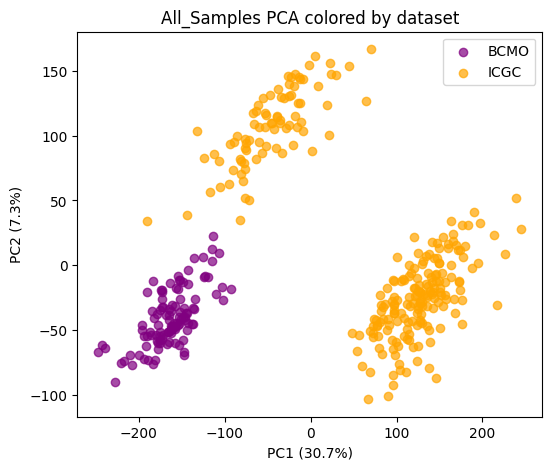

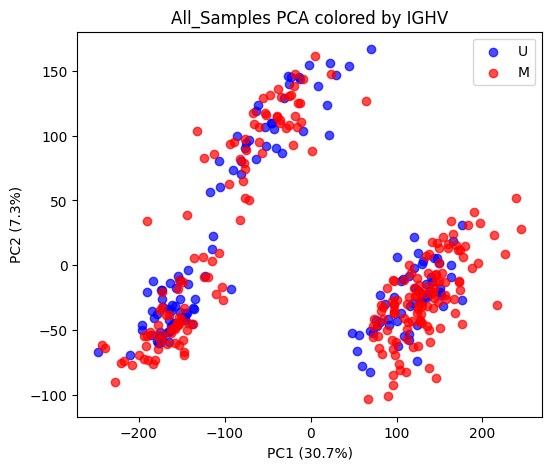

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1️⃣ Load the count matrices and metadata
bcmo_counts = pd.read_csv("../../data/BCMO/count_matrix.csv", index_col=0)   # genes as rows, samples as columns?
bcmo_meta = pd.read_csv("../../data/BCMO/metadata.csv")

icgc_counts = pd.read_csv("../../data/ICGC/count_matrix.csv", index_col=0)
icgc_meta = pd.read_csv("../../data/ICGC/metadata.csv")

# 2️⃣ Match samples in counts and metadata
# For BCMO
bcmo_counts = bcmo_counts[bcmo_meta["Sample_ID"]]
# Log2 transform BCMO counts
bcmo_counts = (bcmo_counts + 1).apply(np.log2)

# For ICGC
icgc_counts = icgc_counts[icgc_meta["Samples"]]

# 3️⃣ Keep only common genes
common_genes = bcmo_counts.index.intersection(icgc_counts.index)
bcmo_counts = bcmo_counts.loc[common_genes]
icgc_counts = icgc_counts.loc[common_genes]

# 4️⃣ Define a function to perform PCA and plot
def pca_plot(counts, metadata, color_by, title_prefix):
    # transpose to have samples as rows
    data = counts.T
    
    # PCA
    pca = PCA(n_components=2)
    pca_res = pca.fit_transform(data)
    explained_var = pca.explained_variance_ratio_ * 100  # percentage

    # Define custom colors
    if color_by == "dataset":
        color_map = {"BCMO": "purple", "ICGC": "orange"}
    elif color_by == "IGHV":
        color_map = {"U": "blue", "M": "red"}
    else:
        color_map = {status: None for status in metadata[color_by].unique()}
    
    # Plot PCA
    plt.figure(figsize=(6,5))
    for status in metadata[color_by].unique():
        idx = metadata[color_by] == status
        plt.scatter(
            pca_res[idx,0], pca_res[idx,1],
            label=status,
            alpha=0.7,
            color=color_map.get(status, None)
        )
    plt.title(f"{title_prefix} PCA colored by {color_by}")
    plt.xlabel(f"PC1 ({explained_var[0]:.1f}%)")
    plt.ylabel(f"PC2 ({explained_var[1]:.1f}%)")
    plt.legend()

    # Save figure (300 dpi PNG)
    plt.savefig(f"../../figures/PCA_{title_prefix}_{color_by}.png", dpi=300, bbox_inches="tight")
    plt.show()

# 5️⃣ Apply by dataset
bcmo_meta["dataset"] = "BCMO"
icgc_meta["dataset"] = "ICGC"

combined_counts = pd.concat([bcmo_counts, icgc_counts], axis=1)
combined_meta = pd.concat([
    bcmo_meta.rename(columns={"Sample_ID":"Sample"}),
    icgc_meta.rename(columns={"Samples":"Sample"})
], ignore_index=True)

# Align counts to metadata
combined_counts = combined_counts[combined_meta["Sample"]]

# PCA colored by dataset
pca_plot(combined_counts, combined_meta, color_by="dataset", title_prefix="All_Samples")

# PCA colored by IGHV status
pca_plot(combined_counts, combined_meta, color_by="IGHV", title_prefix="All_Samples")


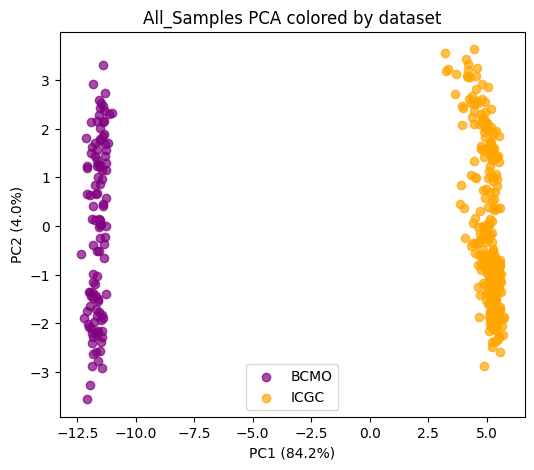

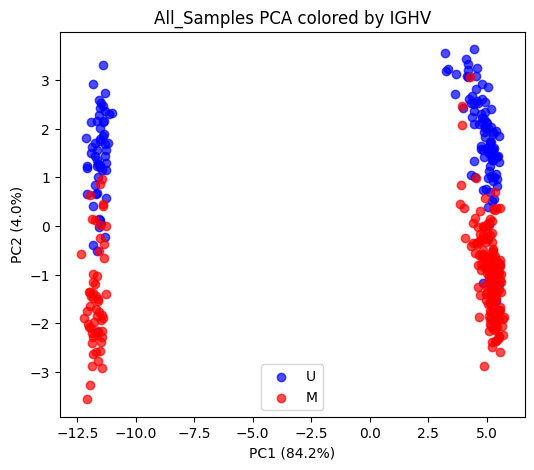

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1️⃣ Load the activity matrices and metadata
bcmo_counts = pd.read_csv("../../data/BCMO/activity_matrix_pvalfilt.csv", index_col=0)   # genes as rows, samples as columns
bcmo_meta = pd.read_csv("../../data/BCMO/metadata.csv")

icgc_counts = pd.read_csv("../../data/ICGC/activity_matrix_pvalfilt.csv", index_col=0)
icgc_meta = pd.read_csv("../../data/ICGC/metadata.csv")

# 2️⃣ Match samples in counts and metadata
# For BCMO
missing_bcmo = set(bcmo_meta["Sample_ID"]) - set(bcmo_counts.columns)
if missing_bcmo:
    print("⚠️ BCMO metadata samples missing in count matrix:", missing_bcmo)

bcmo_counts = bcmo_counts[bcmo_meta["Sample_ID"]]
bcmo_counts = (bcmo_counts + 1).apply(np.log2)  # log2 transform

# For ICGC
missing_icgc = set(icgc_meta["Samples"]) - set(icgc_counts.columns)
if missing_icgc:
    print("⚠️ ICGC metadata samples missing in count matrix:", missing_icgc)

icgc_counts = icgc_counts[icgc_meta["Samples"]]

# 3️⃣ Keep only common genes
common_genes = bcmo_counts.index.intersection(icgc_counts.index)
bcmo_counts = bcmo_counts.loc[common_genes]
icgc_counts = icgc_counts.loc[common_genes]

# 4️⃣ PCA plotting function
def pca_plot(counts, metadata, color_by, title_prefix):
    # transpose to have samples as rows
    data = counts.T
    
    # Drop NaN values (safe for PCA)
    data = data.dropna(axis=0, how="any")
    
    # Keep aligned metadata
    metadata = metadata.loc[metadata["Sample"].isin(data.index)]
    
    # PCA
    pca = PCA(n_components=2)
    pca_res = pca.fit_transform(data)
    explained_var = pca.explained_variance_ratio_ * 100  # percentage

    # Define custom colors
    if color_by == "dataset":
        color_map = {"BCMO": "purple", "ICGC": "orange"}
    elif color_by == "IGHV":
        color_map = {"U": "blue", "M": "red"}
    else:
        color_map = {status: None for status in metadata[color_by].unique()}
    
    # Plot PCA
    plt.figure(figsize=(6,5))
    for status in metadata[color_by].unique():
        idx = metadata[color_by] == status
        plt.scatter(
            pca_res[idx,0], pca_res[idx,1],
            label=status,
            alpha=0.7,
            color=color_map.get(status, None)
        )
    plt.title(f"{title_prefix} PCA colored by {color_by}")
    plt.xlabel(f"PC1 ({explained_var[0]:.1f}%)")
    plt.ylabel(f"PC2 ({explained_var[1]:.1f}%)")
    plt.legend()

    # Save figure (300 dpi PNG)
    plt.savefig(f"../../figures/PCA_{title_prefix}_{color_by}.png", dpi=300, bbox_inches="tight")
    plt.show()

# 5️⃣ Combine datasets
bcmo_meta["dataset"] = "BCMO"
icgc_meta["dataset"] = "ICGC"

combined_counts = pd.concat([bcmo_counts, icgc_counts], axis=1)
combined_meta = pd.concat([
    bcmo_meta.rename(columns={"Sample_ID":"Sample"}),
    icgc_meta.rename(columns={"Samples":"Sample"})
], ignore_index=True)

# Align counts to metadata
combined_counts = combined_counts[combined_meta["Sample"]]

# Handle NaNs introduced by misalignment
if combined_counts.isna().any().any():
    print("⚠️ NaN values detected in combined counts — dropping genes/samples with NaN")
    combined_counts = combined_counts.dropna(axis=0, how="any")
    combined_counts = combined_counts.dropna(axis=1, how="any")

# PCA colored by dataset
pca_plot(combined_counts, combined_meta, color_by="dataset", title_prefix="All_Samples")

# PCA colored by IGHV status
pca_plot(combined_counts, combined_meta, color_by="IGHV", title_prefix="All_Samples")


Total samples in count matrix: 257
Total samples in metadata: 254
Overlapping samples: 254


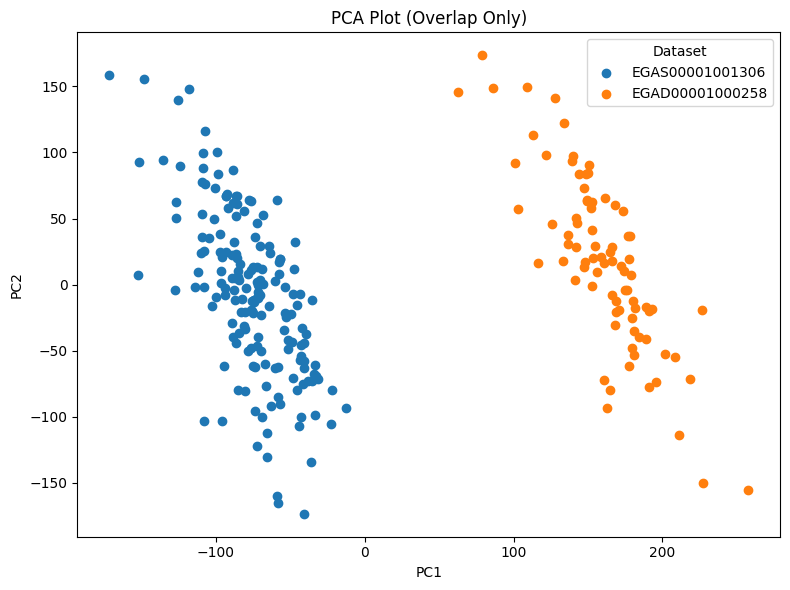

In [9]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# === Load data ===
count_matrix_path = "../../../../data/ICGC/count_matrix.csv"
meta_path = "../../../../data/ICGC/meta_datasets.csv"

count_matrix = pd.read_csv(count_matrix_path, index_col=0)
meta = pd.read_csv(meta_path)

# === Prepare data ===
# Transpose so samples = rows
X = count_matrix.T

# Find overlapping samples
overlap = X.index.intersection(meta["samples"])

print(f"Total samples in count matrix: {len(X.index)}")
print(f"Total samples in metadata: {len(meta['samples'])}")
print(f"Overlapping samples: {len(overlap)}")

# Filter both datasets to overlapping samples only
X = X.loc[overlap]
meta = meta.set_index("samples").loc[overlap]

# === PCA ===
pca = PCA(n_components=2)
pc = pca.fit_transform(X)

pca_df = pd.DataFrame({
    "PC1": pc[:, 0],
    "PC2": pc[:, 1],
    "dataset": meta["dataset"].values
}, index=X.index)

# === Plot ===
plt.figure(figsize=(8, 6))

datasets = pca_df["dataset"].unique()
colors = plt.cm.tab10(range(len(datasets)))

for ds, c in zip(datasets, colors):
    subset = pca_df[pca_df["dataset"] == ds]
    plt.scatter(subset["PC1"], subset["PC2"], label=ds, c=[c])

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Plot (Overlap Only)")
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

Total samples in count matrix: 257
Total samples in metadata: 254
Overlapping samples: 254


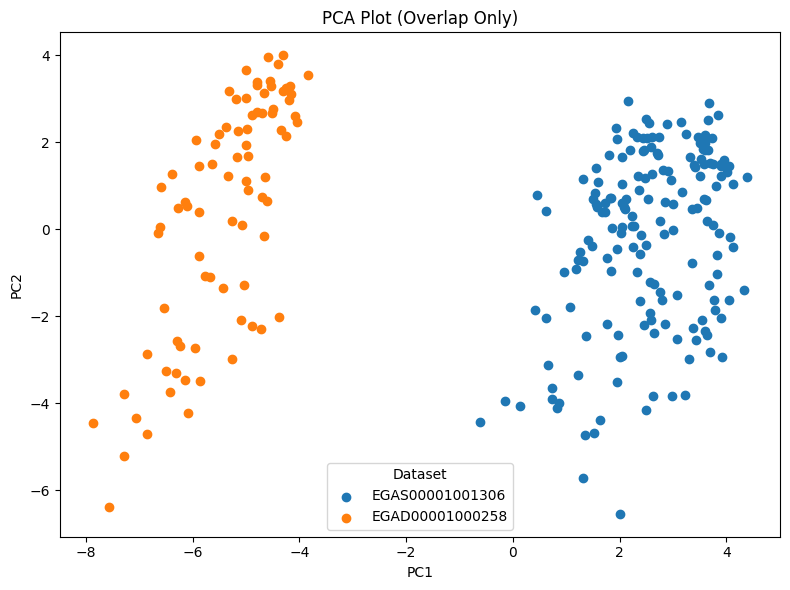

In [11]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# === Load data ===
count_matrix_path = "../../../../data/ICGC/activity_matrix_pvalfilt.csv"
meta_path = "../../../../data/ICGC/meta_datasets.csv"

count_matrix = pd.read_csv(count_matrix_path, index_col=0)
meta = pd.read_csv(meta_path)

# === Prepare data ===
# Transpose so samples = rows
X = count_matrix.T

# Find overlapping samples
overlap = X.index.intersection(meta["samples"])

print(f"Total samples in count matrix: {len(X.index)}")
print(f"Total samples in metadata: {len(meta['samples'])}")
print(f"Overlapping samples: {len(overlap)}")

# Filter both datasets to overlapping samples only
X = X.loc[overlap]
meta = meta.set_index("samples").loc[overlap]

# === PCA ===
pca = PCA(n_components=2)
pc = pca.fit_transform(X)

pca_df = pd.DataFrame({
    "PC1": pc[:, 0],
    "PC2": pc[:, 1],
    "dataset": meta["dataset"].values
}, index=X.index)

# === Plot ===
plt.figure(figsize=(8, 6))

datasets = pca_df["dataset"].unique()
colors = plt.cm.tab10(range(len(datasets)))

for ds, c in zip(datasets, colors):
    subset = pca_df[pca_df["dataset"] == ds]
    plt.scatter(subset["PC1"], subset["PC2"], label=ds, c=[c])

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Plot (Overlap Only)")
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

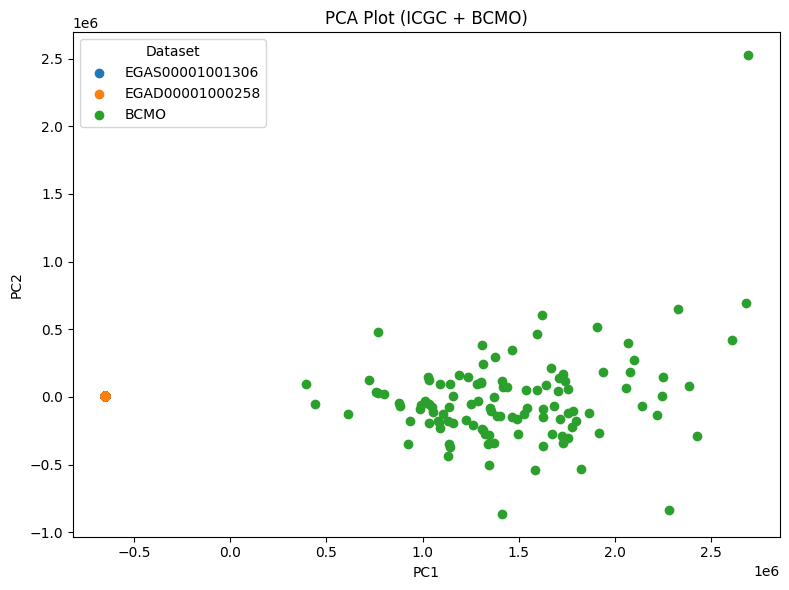

In [13]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

# === Load data ===
# ICGC
icgc_counts_path = "../../../../data/ICGC/count_matrix.csv"
icgc_meta_path = "../../../../data/ICGC/meta_datasets.csv"
icgc_counts = pd.read_csv(icgc_counts_path, index_col=0)
icgc_meta = pd.read_csv(icgc_meta_path)

# BCMO
bcmo_counts_path = "../../../../data/BCMO/count_matrix.csv"
bcmo_counts = pd.read_csv(bcmo_counts_path, index_col=0)

# === Prepare ICGC data ===
X_icgc = icgc_counts.T
overlap_icgc = X_icgc.index.intersection(icgc_meta["samples"])
X_icgc = X_icgc.loc[overlap_icgc]
meta_icgc = icgc_meta.set_index("samples").loc[overlap_icgc]

# === Prepare BCMO data ===
X_bcmo = bcmo_counts.T
meta_bcmo = pd.DataFrame({
    "dataset": ["BCMO"] * X_bcmo.shape[0]
}, index=X_bcmo.index)

# === Align features (genes) between ICGC and BCMO ===
common_genes = X_icgc.columns.intersection(X_bcmo.columns)
X_icgc = X_icgc[common_genes]
X_bcmo = X_bcmo[common_genes]

# === Combine datasets ===
X_all = pd.concat([X_icgc, X_bcmo], axis=0)
meta_all = pd.concat([meta_icgc[["dataset"]], meta_bcmo], axis=0)

# === Impute missing values with mean per gene ===
imputer = SimpleImputer(strategy="mean")
X_all_imputed = pd.DataFrame(imputer.fit_transform(X_all),
                             index=X_all.index,
                             columns=X_all.columns)

# === PCA ===
pca = PCA(n_components=2)
pc = pca.fit_transform(X_all_imputed)

pca_df = pd.DataFrame({
    "PC1": pc[:, 0],
    "PC2": pc[:, 1],
    "dataset": meta_all["dataset"].values
}, index=X_all.index)

# === Plot ===
plt.figure(figsize=(8, 6))

datasets = pca_df["dataset"].unique()
colors = plt.cm.tab10(range(len(datasets)))

for ds, c in zip(datasets, colors):
    subset = pca_df[pca_df["dataset"] == ds]
    plt.scatter(subset["PC1"], subset["PC2"], label=ds, c=[c])

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Plot (ICGC + BCMO)")
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()


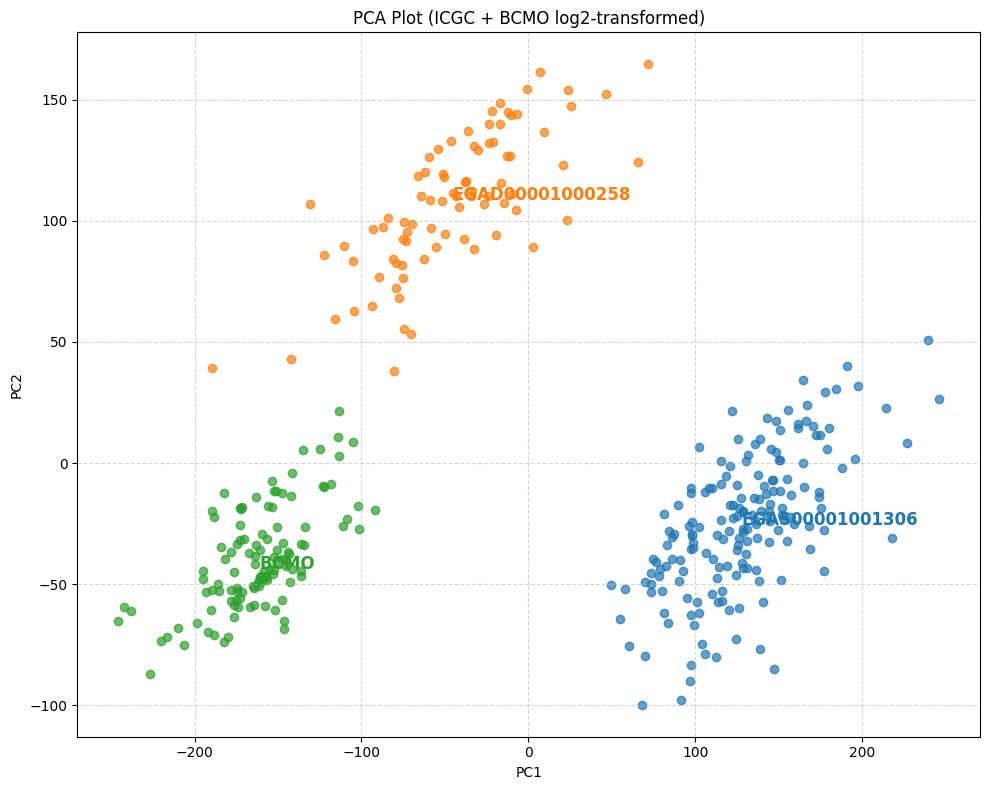

In [17]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

# === Load data ===
# ICGC
icgc_counts_path = "../../../../data/ICGC/count_matrix.csv"
icgc_meta_path = "../../../../data/ICGC/meta_datasets.csv"
icgc_counts = pd.read_csv(icgc_counts_path, index_col=0)
icgc_meta = pd.read_csv(icgc_meta_path)

# BCMO
bcmo_counts_path = "../../../../data/BCMO/count_matrix.csv"
bcmo_counts = pd.read_csv(bcmo_counts_path, index_col=0)

# === Prepare ICGC data ===
X_icgc = icgc_counts.T
overlap_icgc = X_icgc.index.intersection(icgc_meta["samples"])
X_icgc = X_icgc.loc[overlap_icgc]
meta_icgc = icgc_meta.set_index("samples").loc[overlap_icgc]

# === Prepare BCMO data with log2 transformation ===
X_bcmo = bcmo_counts.T
X_bcmo_log2 = np.log2(X_bcmo + 1)  # pseudocount 1 to avoid log2(0)

# Create BCMO metadata
meta_bcmo = pd.DataFrame({
    "dataset": ["BCMO"] * X_bcmo_log2.shape[0]
}, index=X_bcmo_log2.index)

# === Align features (genes) between ICGC and BCMO ===
common_genes = X_icgc.columns.intersection(X_bcmo_log2.columns)
X_icgc = X_icgc[common_genes]
X_bcmo_log2 = X_bcmo_log2[common_genes]

# === Combine datasets ===
X_all = pd.concat([X_icgc, X_bcmo_log2], axis=0)
meta_all = pd.concat([meta_icgc[["dataset"]], meta_bcmo], axis=0)

# === Impute missing values with mean per gene ===
imputer = SimpleImputer(strategy="mean")
X_all_imputed = pd.DataFrame(imputer.fit_transform(X_all),
                             index=X_all.index,
                             columns=X_all.columns)

# === PCA ===
pca = PCA(n_components=2)
pc = pca.fit_transform(X_all_imputed)

pca_df = pd.DataFrame({
    "PC1": pc[:, 0],
    "PC2": pc[:, 1],
    "dataset": meta_all["dataset"].values
}, index=X_all.index)

# === Plot ===
plt.figure(figsize=(10, 8))

datasets = pca_df["dataset"].unique()
colors = plt.cm.tab10(range(len(datasets)))

for ds, c in zip(datasets, colors):
    subset = pca_df[pca_df["dataset"] == ds]
    plt.scatter(subset["PC1"], subset["PC2"], label=ds, c=[c], alpha=0.7)
    
    # Place dataset label at median position of points
    x_median = subset["PC1"].median()
    y_median = subset["PC2"].median()
    plt.text(x_median, y_median, ds, fontsize=12, weight='bold', color=c)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Plot (ICGC + BCMO log2-transformed)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


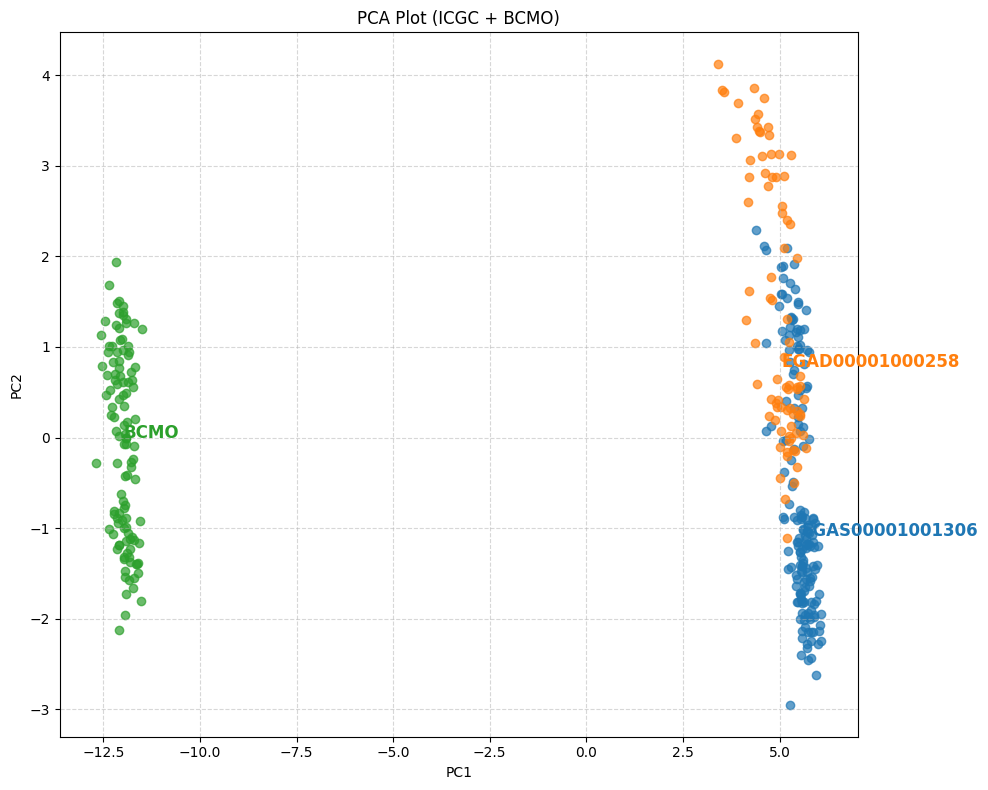

In [19]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

# === Load data ===
# ICGC
icgc_counts_path = "../../../../data/ICGC/activity_matrix_pvalfilt.csv"
icgc_meta_path = "../../../../data/ICGC/meta_datasets.csv"
icgc_counts = pd.read_csv(icgc_counts_path, index_col=0)
icgc_meta = pd.read_csv(icgc_meta_path)

# BCMO
bcmo_counts_path = "../../../../data/BCMO/activity_matrix_pvalfilt.csv"
bcmo_counts = pd.read_csv(bcmo_counts_path, index_col=0)

# === Prepare ICGC data ===
X_icgc = icgc_counts.T
overlap_icgc = X_icgc.index.intersection(icgc_meta["samples"])
X_icgc = X_icgc.loc[overlap_icgc]
meta_icgc = icgc_meta.set_index("samples").loc[overlap_icgc]

# === Prepare BCMO data ===
X_bcmo = bcmo_counts.T
meta_bcmo = pd.DataFrame({
    "dataset": ["BCMO"] * X_bcmo.shape[0]
}, index=X_bcmo.index)

# === Align features (genes) between ICGC and BCMO ===
common_genes = X_icgc.columns.intersection(X_bcmo.columns)
X_icgc = X_icgc[common_genes]
X_bcmo = X_bcmo[common_genes]

# === Combine datasets ===
X_all = pd.concat([X_icgc, X_bcmo], axis=0)
meta_all = pd.concat([meta_icgc[["dataset"]], meta_bcmo], axis=0)

# === Impute missing values with mean per gene ===
imputer = SimpleImputer(strategy="mean")
X_all_imputed = pd.DataFrame(imputer.fit_transform(X_all),
                             index=X_all.index,
                             columns=X_all.columns)

# === PCA ===
pca = PCA(n_components=2)
pc = pca.fit_transform(X_all_imputed)

pca_df = pd.DataFrame({
    "PC1": pc[:, 0],
    "PC2": pc[:, 1],
    "dataset": meta_all["dataset"].values
}, index=X_all.index)

# === Plot ===
plt.figure(figsize=(10, 8))

datasets = pca_df["dataset"].unique()
colors = plt.cm.tab10(range(len(datasets)))

for ds, c in zip(datasets, colors):
    subset = pca_df[pca_df["dataset"] == ds]
    plt.scatter(subset["PC1"], subset["PC2"], label=ds, c=[c], alpha=0.7)
    
    # Place dataset label at median position of points
    x_median = subset["PC1"].median()
    y_median = subset["PC2"].median()
    plt.text(x_median, y_median, ds, fontsize=12, weight='bold', color=c)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Plot (ICGC + BCMO)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


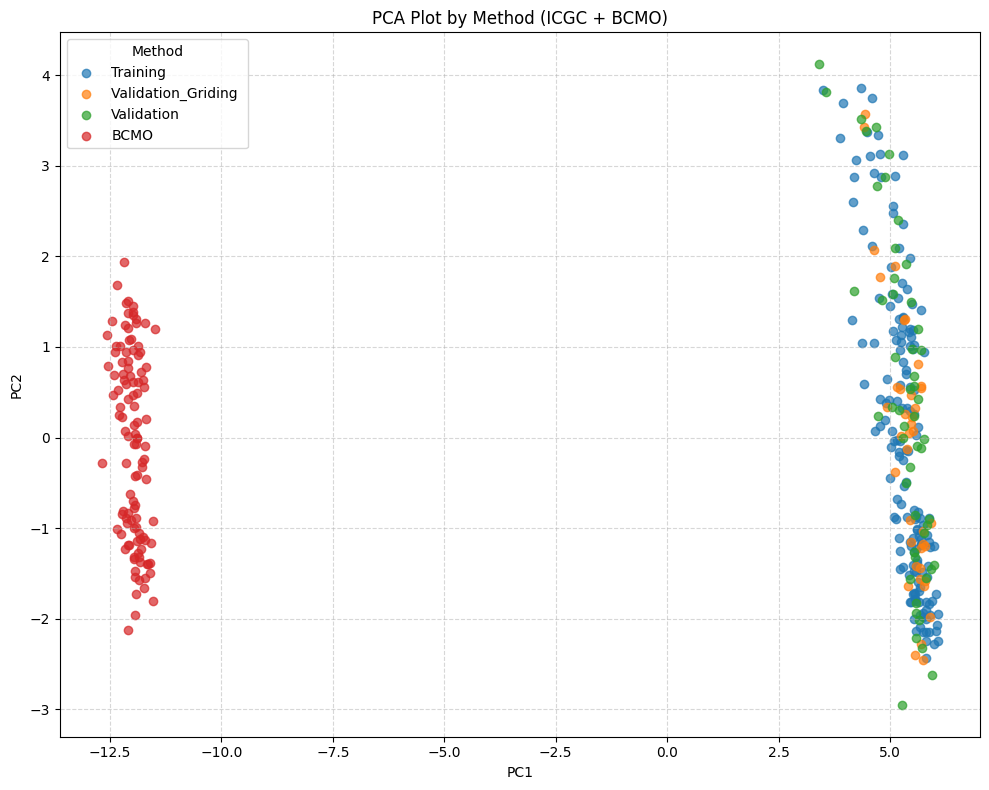

In [27]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

# === Load data ===
# ICGC
icgc_counts_path = "../../../../data/ICGC/activity_matrix_pvalfilt.csv"
icgc_meta_path = "../../../../data/ICGC/meta_datasets.csv"
icgc_counts = pd.read_csv(icgc_counts_path, index_col=0)
icgc_meta = pd.read_csv(icgc_meta_path)

# BCMO
bcmo_counts_path = "../../../../data/BCMO/activity_matrix_pvalfilt.csv"
bcmo_counts = pd.read_csv(bcmo_counts_path, index_col=0)

# === Prepare ICGC data ===
X_icgc = icgc_counts.T
overlap_icgc = X_icgc.index.intersection(icgc_meta["samples"])
X_icgc = X_icgc.loc[overlap_icgc]
meta_icgc = icgc_meta.set_index("samples").loc[overlap_icgc]

# === Prepare BCMO data ===
X_bcmo = bcmo_counts.T
meta_bcmo = pd.DataFrame({
    "method": ["BCMO"] * X_bcmo.shape[0]
}, index=X_bcmo.index)

# === Align features (genes) between ICGC and BCMO ===
common_genes = X_icgc.columns.intersection(X_bcmo.columns)
X_icgc = X_icgc[common_genes]
X_bcmo = X_bcmo[common_genes]

# === Combine datasets ===
X_all = pd.concat([X_icgc, X_bcmo], axis=0)
meta_all = pd.concat([meta_icgc[["method"]], meta_bcmo], axis=0)

# === Impute missing values with mean per gene ===
imputer = SimpleImputer(strategy="mean")
X_all_imputed = pd.DataFrame(imputer.fit_transform(X_all),
                             index=X_all.index,
                             columns=X_all.columns)

# === PCA ===
pca = PCA(n_components=2)
pc = pca.fit_transform(X_all_imputed)

pca_df = pd.DataFrame({
    "PC1": pc[:, 0],
    "PC2": pc[:, 1],
    "method": meta_all["method"].values
}, index=X_all.index)

# === Plot PCA colored by method ===
plt.figure(figsize=(10, 8))

methods = pca_df["method"].unique()
colors = plt.cm.tab10(range(len(methods)))  # Color palette

for m, c in zip(methods, colors):
    subset = pca_df[pca_df["method"] == m]
    plt.scatter(subset["PC1"], subset["PC2"], label=m, color=c, alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Plot by Method (ICGC + BCMO)")
plt.legend(title="Method")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


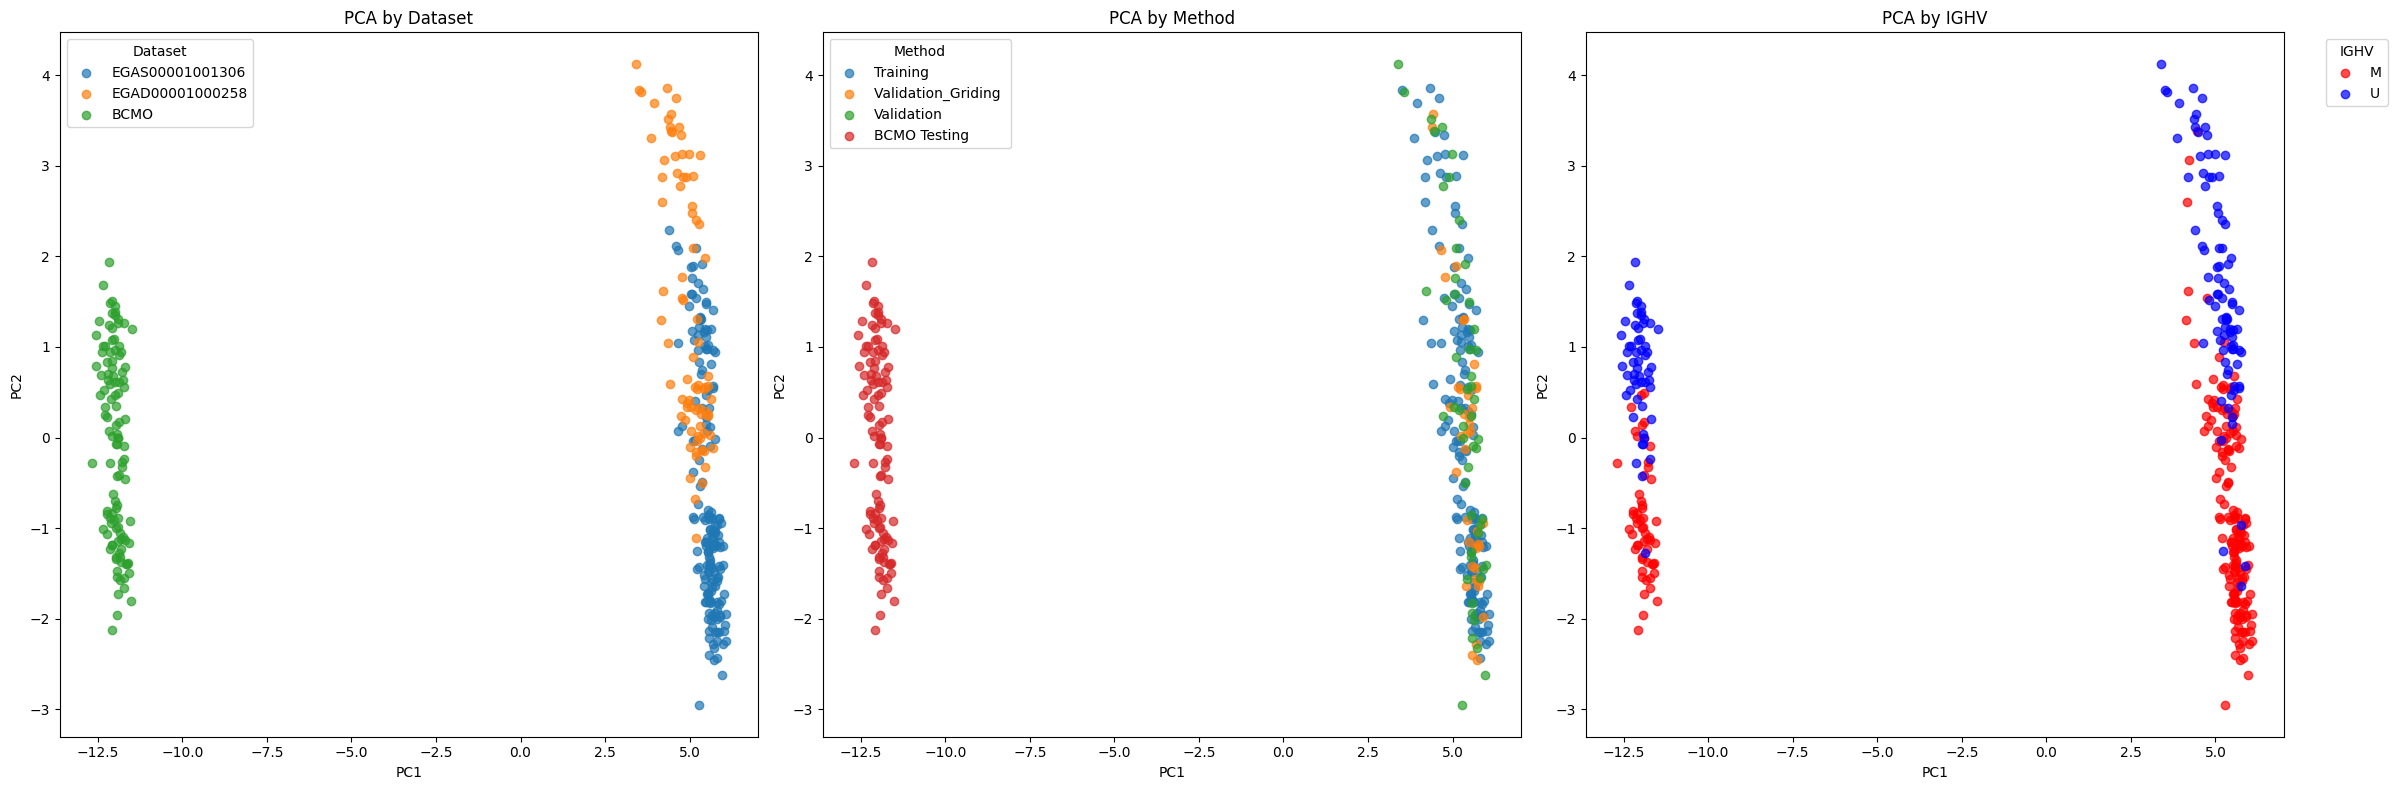

In [41]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

# === Load data ===
# ICGC
icgc_counts_path = "../../../../data/ICGC/activity_matrix_pvalfilt.csv"
icgc_meta_path = "../../../../data/ICGC/meta_datasets.csv"
icgc_counts = pd.read_csv(icgc_counts_path, index_col=0)
icgc_meta = pd.read_csv(icgc_meta_path)

# BCMO
bcmo_counts_path = "../../../../data/BCMO/activity_matrix_pvalfilt.csv"
bcmo_meta_path = "../../../../data/BCMO/metadata.csv"
bcmo_counts = pd.read_csv(bcmo_counts_path, index_col=0)
bcmo_meta = pd.read_csv(bcmo_meta_path, index_col=0)  # assume index = sample names

# === Prepare ICGC data ===
X_icgc = icgc_counts.T
overlap_icgc = X_icgc.index.intersection(icgc_meta["samples"])
X_icgc = X_icgc.loc[overlap_icgc]

meta_icgc = icgc_meta.set_index("samples").loc[overlap_icgc]
meta_icgc = meta_icgc.rename(columns={"method": "method", "IGHV": "IGHV"})

# === Prepare BCMO data ===
X_bcmo = bcmo_counts.T
meta_bcmo = pd.DataFrame({
    "method": ["BCMO Testing"] * X_bcmo.shape[0],
    "dataset": ["BCMO"] * X_bcmo.shape[0]
}, index=X_bcmo.index)

# Add IGHV info
meta_bcmo["IGHV"] = bcmo_meta.reindex(X_bcmo.index)["IGHV"]

# === Align features (genes) ===
common_genes = X_icgc.columns.intersection(X_bcmo.columns)
X_icgc = X_icgc[common_genes]
X_bcmo = X_bcmo[common_genes]

# === Combine data ===
X_all = pd.concat([X_icgc, X_bcmo], axis=0)
meta_all = pd.concat([meta_icgc[["dataset", "method", "IGHV"]],
                      meta_bcmo[["dataset", "method", "IGHV"]]], axis=0)

# === Impute missing values ===
imputer = SimpleImputer(strategy="mean")
X_all_imputed = pd.DataFrame(imputer.fit_transform(X_all),
                             index=X_all.index,
                             columns=X_all.columns)

# === PCA ===
pca = PCA(n_components=2)
pc = pca.fit_transform(X_all_imputed)

pca_df = pd.DataFrame({
    "PC1": pc[:, 0],
    "PC2": pc[:, 1],
}, index=X_all.index)

# Add metadata
pca_df = pd.concat([pca_df, meta_all], axis=1)

# === 1x3 PCA plot ===
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Panel 1: Dataset
ax = axes[0]
for i, d in enumerate(pca_df["dataset"].unique()):
    subset = pca_df[pca_df["dataset"] == d]
    ax.scatter(subset["PC1"], subset["PC2"], label=d, color=plt.cm.tab10(i), alpha=0.7)
ax.set_title("PCA by Dataset")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(title="Dataset")
ax.grid(False)

# Panel 2: Method
ax = axes[1]
for i, m in enumerate(pca_df["method"].unique()):
    subset = pca_df[pca_df["method"] == m]
    ax.scatter(subset["PC1"], subset["PC2"], label=m, color=plt.cm.tab10(i), alpha=0.7)
ax.set_title("PCA by Method")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(title="Method")
ax.grid(False)

# Panel 3: IGHV
ax = axes[2]
pca_ighv = pca_df.dropna(subset=["IGHV"])
uniq_ighv = pca_ighv["IGHV"].unique()
colors = ["red", "blue"]  # alternate red and blue
for i, ig in enumerate(uniq_ighv):
    subset = pca_ighv[pca_ighv["IGHV"] == ig]
    ax.scatter(subset["PC1"], subset["PC2"], label=ig, color=colors[i % 2], alpha=0.7)

ax.set_title("PCA by IGHV")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(title="IGHV", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(False)

plt.tight_layout()
plt.show()
